In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
def read_BGR2RGB(path:str):
    img = cv.imread(path)
    converted_img = cv.cvtColor(img , cv.COLOR_BGR2RGB)
    return converted_img

def display(list_img):
    for index, img in enumerate(list_img):
        cv.imshow(f"Image {index}", img)
    cv.waitKey(0)
    cv.destroyAllWindows()

def apply_all_blurs(thresh , k_size:int = 5):
    # Box Blur (Average Blur)
    box_blur = cv.blur(thresh, (k_size, k_size))
    
    # Gaussian Blur
    gaussian_blur = cv.GaussianBlur(thresh, (k_size, k_size), 0)
    
    # Median Blur
    median_blur = cv.medianBlur(thresh, k_size)
    
    # Bilateral Filter
    bilateral_blur = cv.bilateralFilter(thresh, 9, 75, 75)
    
    display([
        image,
        box_blur,
        gaussian_blur,
        median_blur,
        bilateral_blur
    ])

(<matplotlib.image.AxesImage at 0x736ca17a8050>, numpy.ndarray, (559, 748, 3))

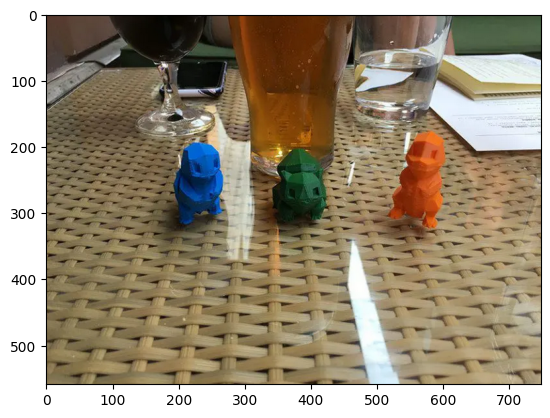

In [2]:
img = read_BGR2RGB("./Data/3d_pokemon.png")
plt.axis('on')
plt.imshow(img) , type(img) , img.shape

In [3]:
crop = img[200:350 , 100:300]

In [4]:
display([img , crop]) , img.shape

QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ fo

(None, (559, 748, 3))

# Color Spaces


In [5]:
img_bgr = cv.imread("./Data/3d_pokemon.png")
img_rgb = read_BGR2RGB("./Data/3d_pokemon.png")
display([img_bgr , img_rgb])

In [6]:
k_size = 7

In [7]:
# Kernel size (must be odd for Gaussian and Median)
k_size = 5

# Box Blur (Average Blur)
box_blur = cv.blur(img, (k_size, k_size))

# Gaussian Blur
gaussian_blur = cv.GaussianBlur(img, (k_size, k_size), 0)

# Median Blur
median_blur = cv.medianBlur(img, k_size)

# Bilateral Filter
bilateral_blur = cv.bilateralFilter(img, 9, 75, 75)

display([
    img,
    box_blur,
    gaussian_blur,
    median_blur,
    bilateral_blur
])


## 1. Box Blur (`cv.blur`)

```python
blurred = cv.blur(img, (5, 5))
```

For each pixel:

* Take all pixels in the 5×5 neighborhood.
* Compute the average.
* Replace the center pixel with that average.

Visualization:

```text
1 1 1
1 X 1
1 1 1
```

Every pixel has equal weight.

### Pros

* Fast
* Simple

### Cons

* Smears edges aggressively
* Can make images look artificial

### Use when

* Quick smoothing
* Performance matters more than quality

---

## 2. Gaussian Blur (`cv.GaussianBlur`)

```python
blurred = cv.GaussianBlur(img, (5, 5), 0)
```

Pixels closer to the center get more importance.

Example weights:

```text
1 2 1
2 4 2
1 2 1
```

Center influences the result most.

### Pros

* More natural looking
* Preserves edges better than box blur
* Reduces camera noise effectively

### Cons

* Slightly slower than box blur

### Use when

* Preprocessing before edge detection
* Removing camera noise
* General-purpose smoothing

Very common before:

```python
cv.Canny(...)
```

because noisy edges can confuse edge detection.

---

## 3. Median Blur (`cv.medianBlur`)

```python
blurred = cv.medianBlur(img, 5)
```

Instead of averaging:

1. Collect neighboring pixel values.
2. Sort them.
3. Pick the middle value.

Example:

```text
10 11 12
13 255 14
15 16 17
```

Sorted:

```text
10 11 12 13 14 15 16 17 255
```

Median:

```text
14
```

The bright noise pixel (`255`) disappears.

### Pros

* Excellent for salt-and-pepper noise
* Preserves edges surprisingly well

### Cons

* More expensive
* Can remove small details

### Use when

Image contains random white/black dots:

```text
salt-and-pepper noise
```

---

## 4. Bilateral Filter (`cv.bilateralFilter`)

```python
blurred = cv.bilateralFilter(img, 9, 75, 75)
```

This filter considers:

* Distance between pixels
* Difference in color/intensity

If neighboring pixels are very different, it avoids averaging them.

### Pros

* Smooths flat areas
* Keeps edges sharp

### Cons

* Much slower
* Expensive on large images

### Use when

You want:

```text
Noise removed
+
Edges preserved
```

Common in:

* Portrait smoothing
* Cartoon effects
* Beauty filters

---


In [1]:
import cv2
import matplotlib.pyplot as plt
cam = cv2.VideoCapture(0)

while True:
    check, frame = cam.read()

    if not check:
        print("Failed to capture frame")
        break
    cv2.imshow("video", frame)
    key = cv2.waitKey(1) & 0xFF

    # Exit when ESC or q is pressed
    if key == 27 or key == ord('q'):
        break

cam.release()
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ fo

In [21]:
import cv2 as cv
image = cv.imread("./Data/imageTextN.png")
image_gray = cv.cvtColor(image , cv.COLOR_BGR2GRAY)
# display([image , image_gray])

In [13]:
_ , thresh = cv.threshold(image_gray , 127 , 255 , cv.THRESH_BINARY)
apply_all_blurs(thresh , 7)

In [14]:
thresh = cv.adaptiveThreshold(
    image_gray,
    255,
    cv.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv.THRESH_BINARY,
    11,
    2
)
apply_all_blurs(thresh , 7)

In [22]:
blur = cv.GaussianBlur(image_gray, (5,5), 0)

_, thresh = cv.threshold(
    blur,
    0,
    255,
    cv.THRESH_BINARY + cv.THRESH_OTSU
)
display([thresh , image , blur])


# 1. What is thresholding?

You have a grayscale image.

Each pixel has a value:

* 0 = black
* 255 = white

Thresholding converts it into a binary image.

Example:

| Pixel Value | Threshold = 127 | Output      |
| ----------- | --------------- | ----------- |
| 50          | <127            | 0 (black)   |
| 180         | >127            | 255 (white) |
| 100         | <127            | 0           |
| 220         | >127            | 255         |

```python
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
```

127 = cutoff point

255 = white value

Result:

```
Original:        Binary:

50  180          0   255
100 220          0   255
```

---

# 2. THRESH_BINARY

Most common.

```python
_, thresh = cv2.threshold(
    img,
    127,
    255,
    cv2.THRESH_BINARY
)
```

Rule:

```
pixel > threshold  → 255
pixel <= threshold → 0
```

Useful for:

* OCR
* Contour detection
* Shape extraction

---

# 3. THRESH_BINARY_INV

Inverse.

```python
cv2.THRESH_BINARY_INV
```

Rule:

```
pixel > threshold → 0
pixel <= threshold → 255
```

White becomes black and vice versa.

Useful when objects are darker than background.

---

# 4. Why fixed threshold fails

Suppose image has shadows.

```
Left side bright
Right side dark
```

A single threshold like 127 may work on one side and fail on the other.

Example:

```
Object pixel = 100
Background pixel = 90
```

Threshold 127:

Everything becomes black.

Object disappears.

This is where Adaptive Threshold comes in.

---

# 5. Adaptive Threshold

Instead of one threshold for the whole image:

```
Each neighborhood gets its own threshold.
```

```python
cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)
```

The weird parameters:

---

## Block Size

```python
11
```

This is the neighborhood size.

Think:

```
11 x 11 window
```

around each pixel.

OpenCV looks at nearby pixels and calculates a threshold.

Example:

```
blockSize = 11

□□□□□□□
□□□□□□□
□□□X□□□
□□□□□□□
□□□□□□□
```

Threshold for X comes from this local region.

Must be:

* odd number
* > 1

Examples:

```python
3
5
11
15
21
```

Smaller:

* reacts strongly to local changes
* noisier

Larger:

* smoother
* ignores tiny variations

Common values:

```python
11
15
21
```

---

## C parameter

```python
C = 2
```

After calculating local threshold:

```
threshold = local_mean - C
```

Example:

```
Local mean = 120

C = 2

threshold = 118
```

Higher C:

* more pixels become white

Lower C:

* stricter threshold

Common:

```python
2
5
10
```

---

# 6. ADAPTIVE_THRESH_MEAN_C

Threshold = average of neighborhood.

```
threshold = mean - C
```

Simple.

Fast.

Works well for documents.

---

# 7. ADAPTIVE_THRESH_GAUSSIAN_C

Threshold = weighted average.

Nearby pixels matter more.

```
threshold = gaussian weighted mean - C
```

Usually gives cleaner results.

```python
cv2.ADAPTIVE_THRESH_GAUSSIAN_C
```

For many real-world images:

Gaussian > Mean

---

# 8. Otsu Thresholding

This is the one everyone uses but often doesn't understand.

Instead of you choosing:

```python
127
```

Otsu chooses automatically.

```python
_, thresh = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
```

Notice:

```python
0
```

is passed as threshold.

Why?

Because Otsu will find it.

---

## How Otsu thinks

Imagine histogram:

```
Dark pixels       Bright pixels

      /\              /\
     /  \            /  \
----/----\----------/----\----
```

Two peaks.

One peak:

* background

Other peak:

* object

Otsu finds the best separating point.

Something like:

```
threshold = 143
```

automatically.

---

## When Otsu works great

When histogram looks like:

```
dark object
bright background
```

Two clear peaks.

Example:

* scanned document
* black text on white paper

---

## When Otsu fails

If image is unevenly lit:

```
shadow
reflection
sunlight
```

Histogram becomes messy.

Then Adaptive Threshold often wins.

---

# 9. Gaussian Blur + Otsu

Very common pipeline.

```python
blur = cv2.GaussianBlur(img, (5,5), 0)

_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
```

Why blur first?

Removes noise.

Cleaner histogram.

Better Otsu threshold.

---

# Quick rule for Computer Vision projects

### Document OCR

```python
Adaptive Gaussian
```

or

```python
Otsu
```

---

### License Plate

```python
Adaptive Gaussian
```

---

### Cell Detection

```python
Otsu
```

often first choice

---

### Industrial Parts

```python
Otsu
```

if lighting is controlled

---

### Outdoor Images

```python
Adaptive Gaussian
```

usually safer

---

The mental model I want you to keep is:

* **Normal Threshold** → "I choose the cutoff."
* **Otsu** → "Computer chooses one global cutoff."
* **Adaptive Threshold** → "Every region gets its own cutoff."
* **Block Size** → "How much neighborhood to look at."
* **C** → "Adjustment after computing the local threshold."

Once that clicks, 90% of OpenCV thresholding stops being mysterious.


In [2]:
import cv2 as cv
image = cv.imread("./Data/baseball.jpg")
image = cv.GaussianBlur(image , (7,7) , 0)

In [3]:
import numpy as np
canny = cv.Canny(image , 50 , 200)
canny_dilate = cv.dilate(canny , np.ones((3,3) , dtype = np.int8))
canny_erode = cv.erode(canny_dilate , np.ones((3,3) , dtype = np.int8))
display([canny , canny_dilate , canny_erode])

QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/halfy/Desktop/everything/Opencv-learn/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ fo

In [4]:
image = cv.imread("./Data/3d_pokemon.png")
cv.line(image , (0,0) , (image.shape[1], image.shape[0]) ,  [255,0,0] , 2)
cv.circle(image , (image.shape[1]//2+20, image.shape[0]//2) , 230 ,[0,255,0] , 2)
cv.rectangle(image , (0,0) , (image.shape[1], image.shape[0]) ,  [255,0,0] , 2)
cv.putText(image , "Image" , (0,100) , cv.FONT_HERSHEY_COMPLEX ,2 , [0,255,255] ,cv.LINE_4 )
display([image])


In [83]:
image = cv.imread("./Data/detect_blob.png")
img_gray = cv.cvtColor(image , cv.COLOR_BGR2GRAY)
_ , thresh = cv.threshold(img_gray , 0 ,255 ,cv.THRESH_BINARY)

contours , hierachy = cv.findContours(thresh , cv.RETR_TREE , cv.CHAIN_APPROX_SIMPLE)
display([image, thresh])

In [84]:
for cnt in contours:
    if 300>(area:= cv.contourArea(cnt)>500):
        # cv.drawContours(image, cnt , -1 ,(255,0,0) ,-1)
        x1, y1, w, h  = cv.boundingRect(cnt)
        cv.rectangle(image , (x1,y1) ,(x1+w , y1 + h), (0,0,255) , 3)
display([image])